In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load Data
data= pd.read_excel("C:/Multiple_Disease/kidney_disease.xlsx")

In [ ]:
data

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [8]:
print(data.shape)

(400, 26)


In [9]:
print(data.head())

   id   age    bp     sg   al   su     rbc        pc         pcc          ba  \
0   0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2   2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3   3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4   4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

   ...  pcv    wc   rc  htn   dm  cad appet   pe  ane classification  
0  ...   44  7800  5.2  yes  yes   no  good   no   no            ckd  
1  ...   38  6000  NaN   no   no   no  good   no   no            ckd  
2  ...   31  7500  NaN   no  yes   no  poor   no  yes            ckd  
3  ...   32  6700  3.9  yes   no   no  poor  yes  yes            ckd  
4  ...   35  7300  4.6   no   no   no  good   no   no            ckd  

[5 rows x 26 columns]


In [10]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [11]:
# Check missing values & target distribution
print(data.isnull().sum())

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [12]:
data = data.fillna("None")

In [13]:
print(data.isnull().sum())

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64


In [14]:
# Check Duplicates
duplicates = data[data.duplicated()]
print("Total duplicate rows:",len(duplicates))

Total duplicate rows: 0


In [15]:
# Delete Unwanted Columns
data = data.drop(["id"], axis = 1)

In [16]:
counts = data['classification'].value_counts()
print(counts)

classification
ckd       250
notckd    150
Name: count, dtype: int64


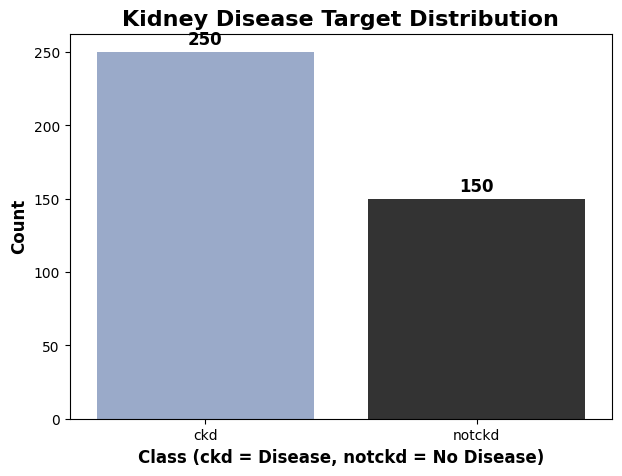

In [17]:
colors = ["#92A8D1", "#333333"]

plt.figure(figsize=(7,5))
sns.barplot(x=counts.index, y=counts.values, palette=colors)

plt.title("Kidney Disease Target Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Class (ckd = Disease, notckd = No Disease)", fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12, fontweight='bold')

for i, val in enumerate(counts.values):
    plt.text(i, val + 5, str(val), ha='center', fontsize=12, fontweight='bold')

plt.show()

In [18]:
# After loading dataset
data['classification'] = data['classification'].str.strip().str.lower()

# Map target
data['target'] = data['classification'].map({'ckd': 1, 'notckd': 0})

# Drop old column
data = data.drop(columns=['classification'])

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
import joblib
import os

In [20]:
cols_to_convert = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']
data[cols_to_convert] = data[cols_to_convert].astype(str)

In [21]:
# define columns
X = data.drop(columns=['target'])
y = data['target']

# Separate numeric and categorical features
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", num_features)
print("Categorical features:", cat_features)

Numeric features: []
Categorical features: ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [22]:
# Numeric pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # fill NaN with median
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),  # fill NaN with "None"
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preproc = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,         # 80% train, 20% test
    stratify=y,            # keeps class distribution same
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Attrition rate in training set:")
print(y_train.value_counts(normalize=True))

Train shape: (320, 24) (320,)
Test shape: (80, 24) (80,)
Attrition rate in training set:
target
1    0.625
0    0.375
Name: proportion, dtype: float64


In [31]:
#- baseline pipeline
clf = Pipeline([
    ('preproc', preproc),
    ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
])

# fit
clf.fit(X_train, y_train)
print("Baseline trained.")

Baseline trained.


In [32]:
#- evaluation
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

ROC AUC: 1.0


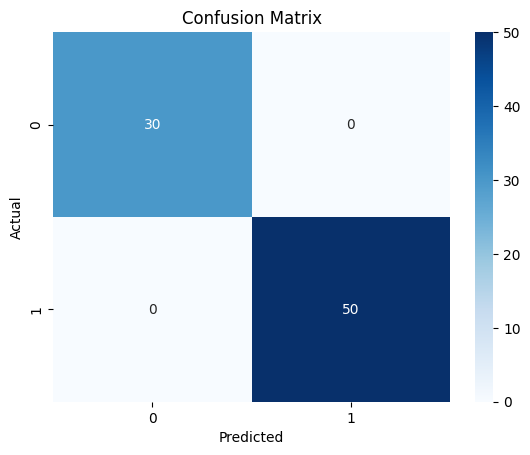

In [33]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

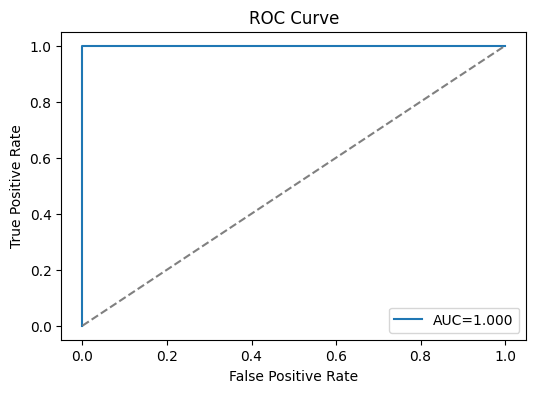

In [34]:
# ROC curve
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_test_num = le.fit_transform(y_test)  # 'ckd' -> 1, 'notckd' -> 0

fpr, tpr, _ = roc_curve(y_test_num, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test_num, y_proba):.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [35]:
# - randomized search (faster than grid)
param_dist = {
    'clf__n_estimators': [100, 200, 400],
    'clf__max_depth': [None, 8, 16, 32],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4]
}

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
search = RandomizedSearchCV(clf, param_dist, n_iter=20, scoring='roc_auc',
                            cv=cv, n_jobs=-1, random_state=42, verbose=1)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
best_model = search.best_estimator_

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best params: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_depth': 16}


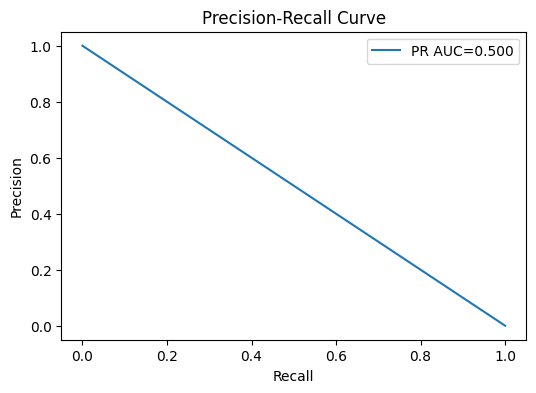

In [36]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

y_proba_best = best_model.predict_proba(X_test)[:,1]

prec, rec, _ = precision_recall_curve(y_test, y_proba_best, pos_label='ckd')  # specify positive class
pr_auc = auc(rec, prec)

plt.figure(figsize=(6,4))
plt.plot(rec, prec, label=f"PR AUC={pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [37]:
# get feature names (scikit-learn >=1.0 supports get_feature_names_out)
pre = best_model.named_steps['preproc']
try:
    # if you pass original columns, get readable names
    feature_names = pre.get_feature_names_out(X_train.columns)
except Exception:
    # fallback - best-effort
    # numeric names + onehot categories (for older sklearn this is a bit more manual)
    feature_names = []
    # numeric:
    if hasattr(pre, 'transformers_'):
        for name, trans, cols in pre.transformers_:
            if name == 'num':
                feature_names.extend(cols)
            elif name == 'cat':
                # get categories from fitted onehot
                ohe = trans.named_steps['onehot']
                cats = ohe.get_feature_names_out(cols)
                feature_names.extend(cats)
print("Number of features after transform:", len(feature_names))

Number of features after transform: 806


In [38]:
# - saving
os.makedirs("models", exist_ok=True)
# save best_model (pipeline includes preproc)
joblib.dump(best_model, "models/kidney_pipeline_best.joblib")
print("Saved models/kidney_pipeline_best.joblib")
# If you want to save preprocessor and classifier separately:
joblib.dump(best_model.named_steps['preproc'], "models/preprocessor_kidney.joblib")
joblib.dump(best_model.named_steps['clf'], "models/kidney_clf_only.joblib")

Saved models/kidney_pipeline_best.joblib


['models/kidney_clf_only.joblib']